In [ ]:
from flower_model._kmeans import _spherical_kmeans
from flower_model.external._gabor_like_filters import _gabor_like_filters
from flower_model._filterbank import _shift_filters
import torch
import matplotlib.pyplot as plt
import math
import numpy as np

In [2]:
N = 31
sigma = 20.
k = 1000
steps = 8
SPH_KMEANS_ITERS = 100
device='cuda'

high_freq_upper = 5.
low_freq_lower= 8.

In [3]:
filters, r = _gabor_like_filters(N, sigma, 15, 1)
print(filters.shape)
print(r.shape)

/cluster/home/vetletb/projects/Bacheloroppgave-gr82-feature-extraction/src/gabor_like/external/_gaussian.py:21: RuntimeWarning: invalid value encountered in divide
  (n + np.array([l1, l2]).reshape(-1, 1, 1))


(736, 31, 31)
(736,)


In [4]:
filters = filters.astype("complex64")
filters = torch.tensor(filters, device=device)
filters = torch.abs(filters)

r = torch.tensor(r, device=device)

In [5]:
filters = _shift_filters(filters, steps, N+1)
shift_dim = filters.size(dim=1)

r = r.repeat((steps*2)**2)

print(filters.shape)
print(r.shape)

torch.Size([188416, 46, 46])
torch.Size([188416])


In [6]:
filter_amount = filters.size(dim=0)
filters = filters.view(filter_amount, -1)

In [7]:
labels = _spherical_kmeans(k, filters, SPH_KMEANS_ITERS)

In [8]:
high_freq_mask = r < high_freq_upper
mid_freq_mask = (r >= high_freq_upper) & (r <= low_freq_lower)
low_freq_mask = r > low_freq_lower

print(high_freq_mask.shape)
print(labels.shape)

torch.Size([188416])
torch.Size([188416])


In [18]:
centroid_list = []
for cluster in range(k):
    cluster_mask = labels == cluster
    high_cluster_mask = cluster_mask & high_freq_mask
    mid_cluster_mask = cluster_mask & mid_freq_mask
    low_cluster_mask = cluster_mask & low_freq_mask
    mask = low_cluster_mask
    if torch.equal(mask, cluster_mask):
        cluster_idx = cluster
        filters_in_cluster = filters[mask]
        centroid_list.append(torch.mean(filters_in_cluster, dim=0))
centroids = torch.stack(centroid_list)
print(centroids.shape)
centroids = centroids.view(-1, shift_dim*shift_dim)

torch.Size([494, 2116])


torch.Size([130, 2116])


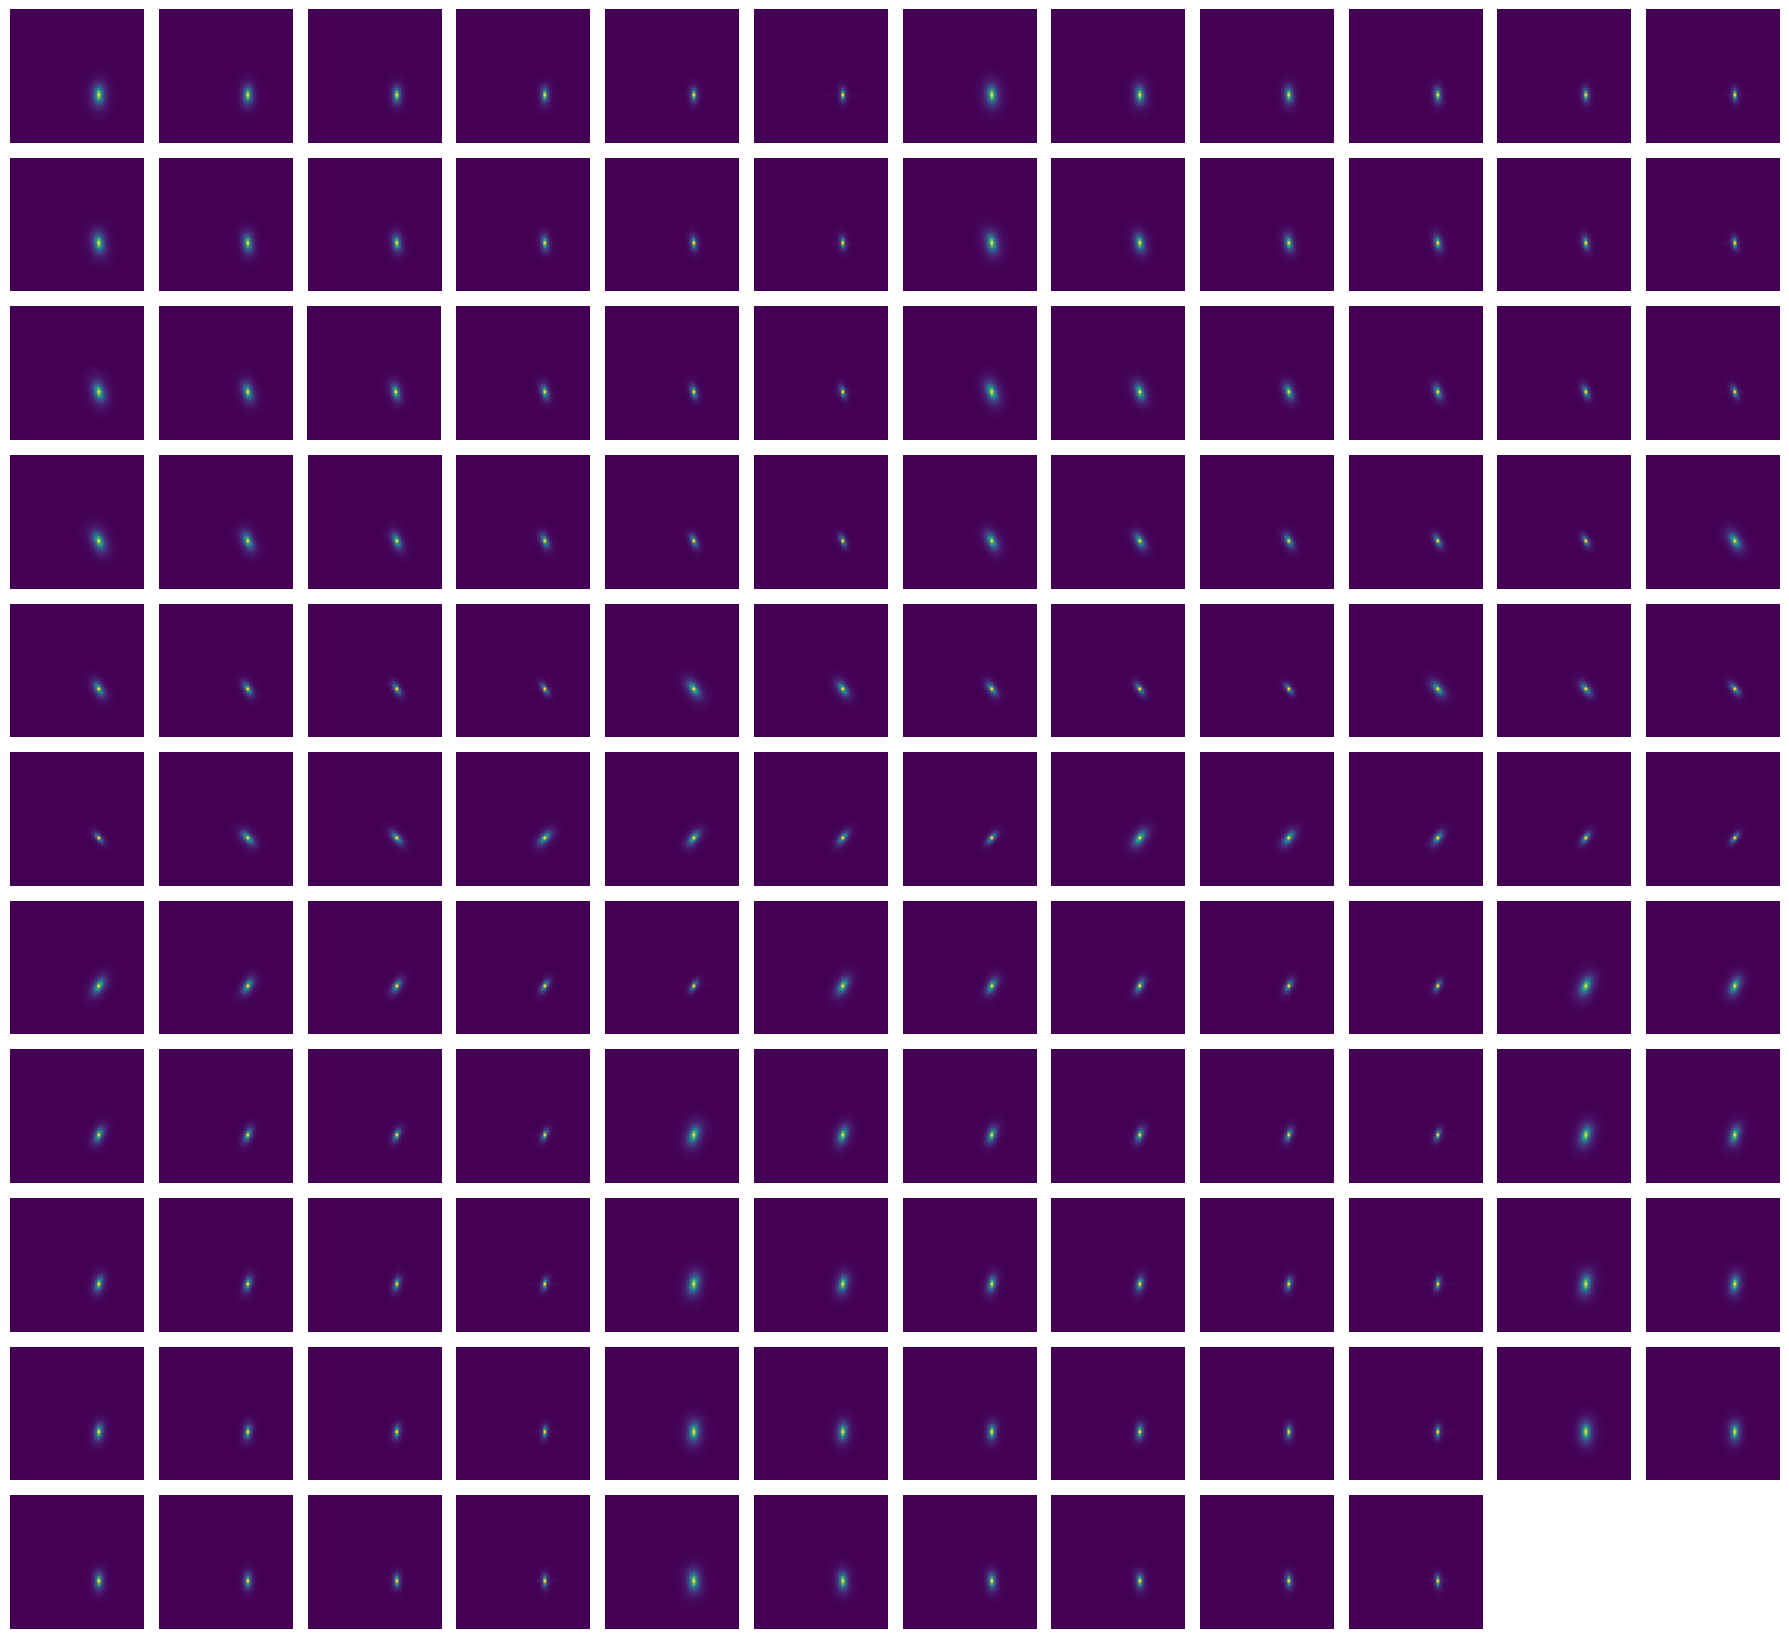

torch.Size([46, 46])


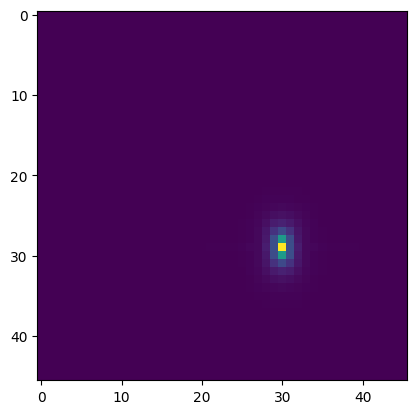

In [19]:
filters_in_cluster = filters[labels == cluster_idx].abs().view(-1, shift_dim*shift_dim)

f = filters_in_cluster.squeeze(0).cpu()        # shape [N, 1024]
print(f.shape)
n = f.shape[0]
size = int(math.sqrt(f.shape[1]))
assert size * size == f.shape[1], "expected square (H*W)"

cols = int(math.ceil(math.sqrt(n)))
rows = int(math.ceil(n / cols))

fig, axes = plt.subplots(rows, cols, figsize=(cols*1.5, rows*1.5))
axes = np.atleast_1d(axes).flatten()

for i in range(rows * cols):
    ax = axes[i]
    if i < n:
        img = f[i].reshape(size, size).numpy()
        ax.imshow(img, cmap="viridis")
    ax.axis("off")

plt.tight_layout()
plt.show()

centroid = torch.mean(filters_in_cluster, dim=0).view(shift_dim, shift_dim).cpu()
print(centroid.shape)
plt.imshow(centroid, cmap='viridis')
plt.show()

torch.Size([494, 2116])


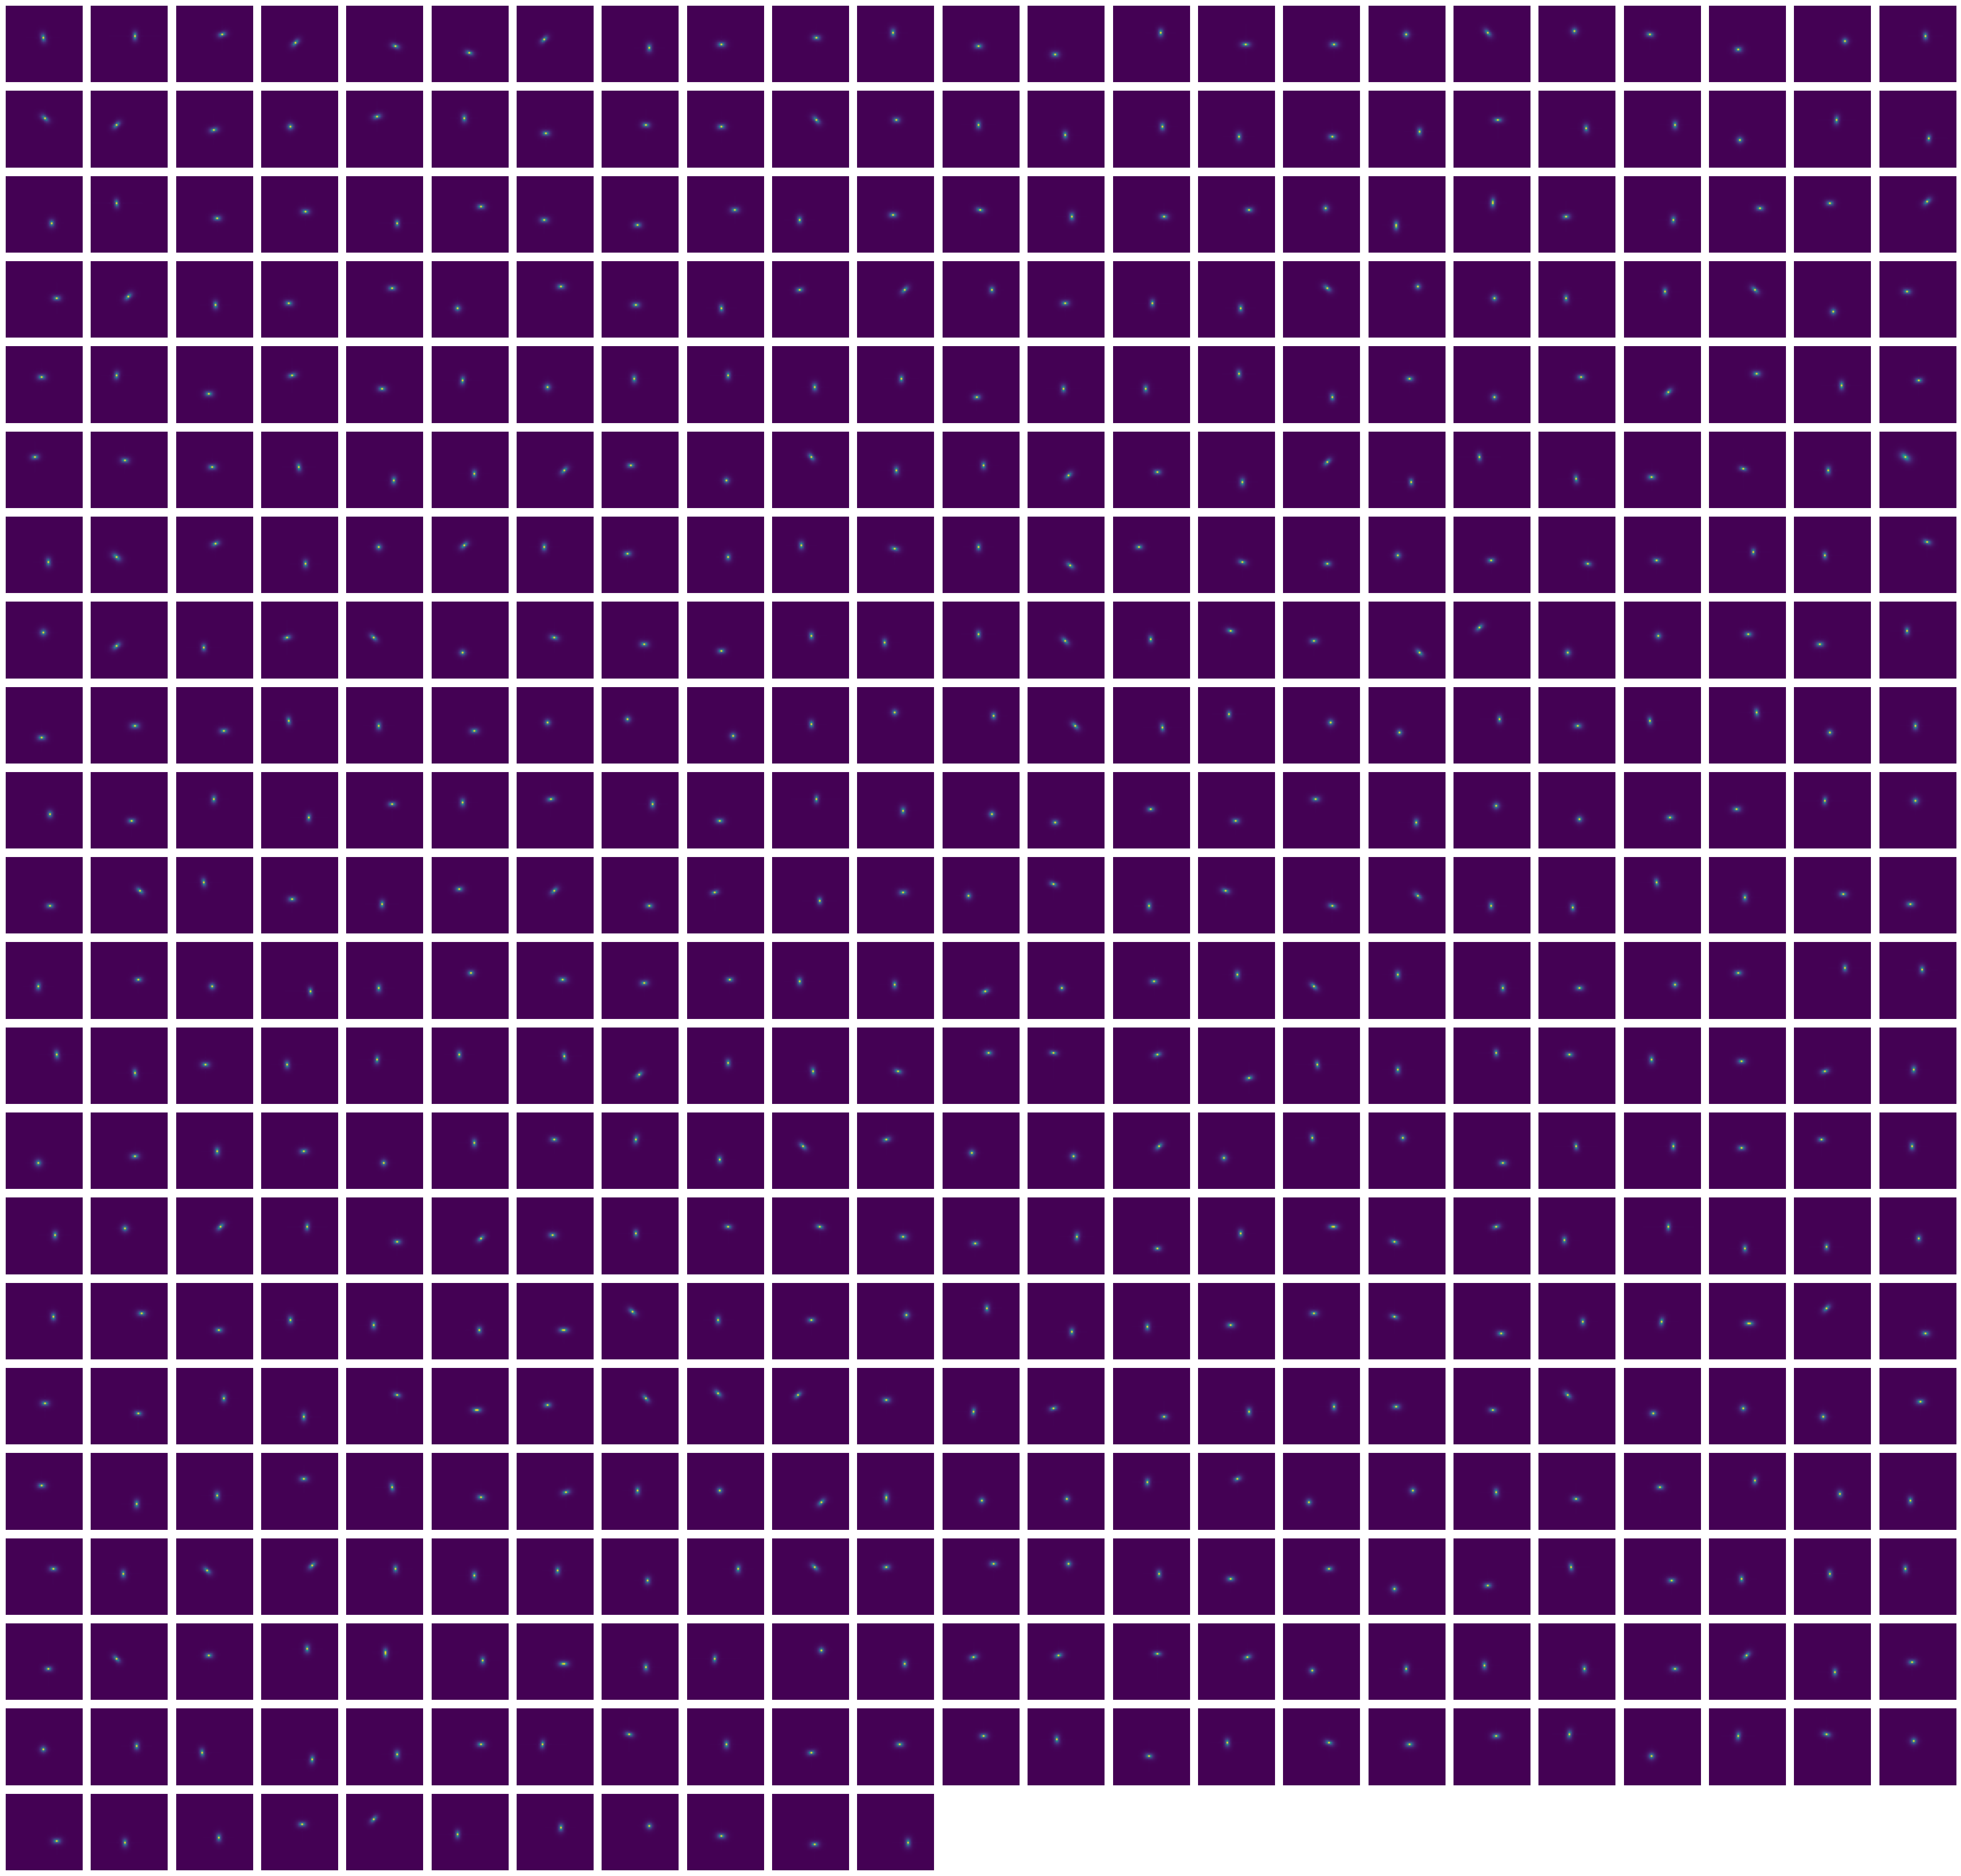

In [20]:
f = centroids.squeeze(0).cpu()        # shape [N, 1024]
print(f.shape)
n = f.shape[0]
size = int(math.sqrt(f.shape[1]))
assert size * size == f.shape[1], "expected square (H*W)"

cols = int(math.ceil(math.sqrt(n)))
rows = int(math.ceil(n / cols))

fig, axes = plt.subplots(rows, cols, figsize=(cols*1.5, rows*1.5))
axes = np.atleast_1d(axes).flatten()

for i in range(rows * cols):
    ax = axes[i]
    if i < n:
        img = f[i].reshape(size, size).numpy()
        ax.imshow(img, cmap="viridis")
    ax.axis("off")

plt.tight_layout()
plt.show()